# Основы глубинного обучения, майнор ИАД

## Домашнее задание 1. Введение в PyTorch. Полносвязные нейронные сети.

### Общая информация

Дата выдачи: 01.10.2023

Мягкий дедлайн: 23:59MSK 15.10.2023

Жесткий дедлайн: 23:59MSK 20.10.2023

### Оценивание и штрафы
Максимально допустимая оценка за работу — 10 баллов. За каждый день просрочки снимается 1 балл. Сдавать задание после жёсткого дедлайна сдачи нельзя.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов. Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке.
Также оценка может быть снижена за плохо читаемый код и плохо оформленные графики. Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

Итогова оценка считается как
$$
min(task_1, task_2)*0.8 + max(task_1, task_2)*0.2
$$

где task_1 и task_2 - оценки за первое и второе заданиее соответсвенно.
Также, за домашнее задание выставляется 0, если не сделано нулевое или третье задание.
### О задании

В этом задании вам предстоит предсказывать год выпуска песни (**задача регрессии**) по некоторым звуковым признакам: [данные](https://archive.ics.uci.edu/ml/datasets/yearpredictionmsd). В ячейках ниже находится код для загрузки данных. Обратите внимание, что обучающая и тестовая выборки располагаются в одном файле, поэтому НЕ меняйте ячейку, в которой производится деление данных.

In [ ]:
import torch
from torch import nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
import random
device = "cuda" if torch.cuda.is_available() else "cpu"
from tqdm.notebook import tqdm
from IPython.display import clear_output
import matplotlib.pyplot as plt

In [ ]:



import os
import urllib.request

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00203/YearPredictionMSD.txt.zip"
if not os.path.exists("data.txt.zip"):
    urllib.request.urlretrieve(url, "data.txt.zip")

In [ ]:
df = pd.read_csv('data.txt.zip', header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,81,82,83,84,85,86,87,88,89,90
0,2001,49.94357,21.47114,73.07750,8.74861,-17.40628,-13.09905,-25.01202,-12.23257,7.83089,...,13.01620,-54.40548,58.99367,15.37344,1.11144,-23.08793,68.40795,-1.82223,-27.46348,2.26327
1,2001,48.73215,18.42930,70.32679,12.94636,-10.32437,-24.83777,8.76630,-0.92019,18.76548,...,5.66812,-19.68073,33.04964,42.87836,-9.90378,-32.22788,70.49388,12.04941,58.43453,26.92061
2,2001,50.95714,31.85602,55.81851,13.41693,-6.57898,-18.54940,-3.27872,-2.35035,16.07017,...,3.03800,26.05866,-50.92779,10.93792,-0.07568,43.20130,-115.00698,-0.05859,39.67068,-0.66345
3,2001,48.24750,-1.89837,36.29772,2.58776,0.97170,-26.21683,5.05097,-10.34124,3.55005,...,34.57337,-171.70734,-16.96705,-46.67617,-12.51516,82.58061,-72.08993,9.90558,199.62971,18.85382
4,2001,50.97020,42.20998,67.09964,8.46791,-15.85279,-16.81409,-12.48207,-9.37636,12.63699,...,9.92661,-55.95724,64.92712,-17.72522,-1.49237,-7.50035,51.76631,7.88713,55.66926,28.74903


Мы вывели кусок данных, чтобы понять, насколько они пригодны для работы без изменений. Здесь ясно, что сомнительно дальше с такими данными работать, потому что как минимум есть отрицательные значения, которые не отмасштабированы, кроме того еще сразу бросается в глаза совсем разная размерность, где-то видим реально большие числа, а где-то 0.075. Ясно, что будем скейлить.

In [ ]:
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

train_size = 463715
X_train = X[:train_size, :]
y_train = y[:train_size]
X_test = X[train_size:, :]
y_test = y[train_size:]

In [ ]:
X.shape

(515345, 90)

## Задание 0. (0 баллов, но при невыполнении максимум за все задание &mdash; 0 баллов)

Мы будем использовать RMSE как метрику качества. Для самого первого бейзлайна обучите `Ridge` регрессию из `sklearn`. Кроме того, посчитайте качество при наилучшем константном прогнозе.

Для выполнения данного задания (и всех последующих) предобработайте данные.

1. Зафиксируйте random_seed везде где только возможно. Вам предоставлена функция для этого, однако вы можете дополнить ее своими дополнениями
2. Обучите StandertScaler и предобработайте ваши данные. В следующих заданиях можете использовать другой scaler или вообще отказаться от него


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [ ]:
def set_random_seed(seed):
    torch.backends.cudnn.deterministic = True
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    # Add smth here if you need...

In [ ]:
set_random_seed(42)

In [ ]:
from sklearn.linear_model import Ridge


X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = Ridge(random_state=42)
model.fit(X_train_scaled, y_train)

y_test_pred = model.predict(X_test_scaled)
rmse_for_model = np.sqrt(np.mean((y_test - y_test_pred) ** 2))
print(f"RMSE Ridge (test): {rmse_for_model:.4f}")

RMSE Ridge (test): 9.5102


Лучшая константа для RMSE это среднее, посчитаем значение метрики при нем

In [ ]:
best_rmse_metric = np.sqrt(np.mean((y_test - y_test_pred.mean()) ** 2))
print(f"RMSE константы среднего: {best_rmse_metric:.4f}")

RMSE константы среднего: 10.8519


## Задание 1. (максимум 10 баллов)

Закрепите свои знания о том, как pytorch работает с обратным распространением ошибки, проделав следующие шаги:

1. Создайте модель линейной регрессии, которая будет состоять только из одного Linear слоя.
2. Напишите цикл обучения вашей линейной регрессии. В нем реализуйте подсчет функции потерь, сделайте шаг градиентного спуска. Запрещено использовать готовые оптимизаторы и loss-функции из библиотеки pytorch. Для подсчета градиента воспользуйтесь методом backward.
3. Запустите обучение на 10 эпохах, после каждой проверяйте значение целевой метрики на тестовой выборке.
4. Выведите на экран графики метрики и значения функции потерь на тестовой и обучающей выборке.

В данном задании нет цели побить какой-то порог по метрике. Ваша задача - убедиться в том, что ваш рукописный цикл обучения работает. Для ускорения вычислений и обучения модели можете брать только срез данных, а не весь датасет.

In [ ]:
# ⸂⸂⸜(രᴗര๑)⸝⸃⸃ Good luck!
from torch.utils.data import DataLoader, TensorDataset

Epoch 1/10: train RMSE=429.7249, test RMSE=9.5508
Epoch 2/10: train RMSE=9.5771, test RMSE=9.5198
Epoch 3/10: train RMSE=9.5655, test RMSE=9.5377
Epoch 4/10: train RMSE=9.5638, test RMSE=9.5189
Epoch 5/10: train RMSE=9.5621, test RMSE=9.5588
Epoch 6/10: train RMSE=9.5588, test RMSE=9.5346
Epoch 7/10: train RMSE=9.5596, test RMSE=9.5302
Epoch 8/10: train RMSE=9.5631, test RMSE=9.5241
Epoch 9/10: train RMSE=9.5638, test RMSE=9.5266
Epoch 10/10: train RMSE=9.5684, test RMSE=9.5625


Text(0.5, 1.0, 'Metric')

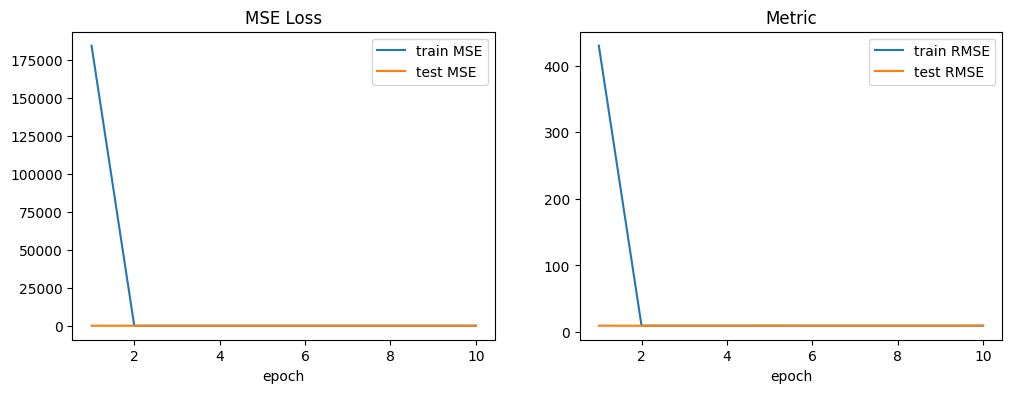

In [ ]:
set_random_seed(42)

# Перевод numpy массивов в тензоры + разворот целевой переменной в столбец
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1) # разворот в столбец (N,) -> (N, 1), иначе broadcasting растянет до (N, N)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1).to(device)
# ...view(-1,1) - # чтобы размерности совпадали с выходом Линейного слоя,
# иначе broadcasting неправильно растянет матрицу и лосс будет неправильным.

# Перемешаем и разделим тренировочные данные на батчи
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=4096, shuffle=True)

linear_model = nn.Linear(X_train_t.shape[1], 1).to(device)

lr = 0.05
n_epochs = 10

train_losses, test_losses, train_rmses, test_rmses = [], [], [], []

for epoch in range(n_epochs):
    epoch_losses = []
    for X_batch, y_batch in train_loader:
        # Перенос тензоров на устройство device
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        # предсказание модели
        y_pred = linear_model(X_batch)
        # среднеквадратичная ошибка
        loss = ((y_pred - y_batch) ** 2).mean()

        # подготовка к шагу градиентного спуска
        linear_model.zero_grad()
        loss.backward()

        # шаг градиетного спуска
        with torch.no_grad():
            # weight и bias
            for param in linear_model.parameters():
                param -= lr * param.grad

            epoch_losses.append(loss.item())


    train_losses.append(np.mean(epoch_losses))
    train_rmses.append((np.mean(epoch_losses) ** 0.5))
    with torch.no_grad():
        test_pred = linear_model(X_test_t)
        test_loss = ((test_pred - y_test_t) ** 2).mean().item()

    test_losses.append(test_loss)
    test_rmses.append(test_loss ** 0.5)

    print(f"Epoch {epoch+1}/{n_epochs}: train RMSE={train_rmses[-1]:.4f}, test RMSE={test_rmses[-1]:.4f}")


epochs = range(1, n_epochs + 1)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label="train MSE")
plt.plot(epochs, test_losses, label="test MSE")
plt.xlabel("epoch")
plt.legend()
plt.title("MSE Loss")

plt.subplot(1, 2, 2)
plt.plot(epochs, train_rmses, label="train RMSE")
plt.plot(epochs, test_rmses, label="test RMSE")
plt.xlabel("epoch")
plt.legend()
plt.title("Metric")

In [ ]:
print(test_losses)
print(test_rmses)

In [ ]:
epochs = range(2, n_epochs + 1)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses[1:], label="train MSE")
plt.plot(epochs, test_losses[1:], label="test MSE")
plt.xlabel("epoch")
plt.legend()
plt.title("MSE Loss")

plt.subplot(1, 2, 2)
plt.plot(epochs, train_rmses[1:], label="train RMSE")
plt.plot(epochs, test_rmses[1:], label="test RMSE")
plt.xlabel("epoch")
plt.legend()
plt.title("Metric")

## Задание 2. (максимум 10 баллов)

Реализуйте обучение и тестирование нейронной сети для предоставленного вам набора данных. Соотношение между полученным значением метрики на тестовой выборке и баллами за задание следующее:

- $\text{RMSE} \le 9.00 $ &mdash; 4 балла
- $\text{RMSE} \le 8.90 $ &mdash; 6 баллов
- $\text{RMSE} \le 8.80 $ &mdash; 8 баллов
- $\text{RMSE} \le 8.75 $ &mdash; 10 баллов

Есть несколько правил, которых вам нужно придерживаться:

- Весь пайплайн обучения должен быть написан на PyTorch. При этом вы можете пользоваться другими библиотеками (`numpy`, `sklearn` и пр.), но только для обработки данных. То есть как угодно трансформировать данные и считать метрики с помощью этих библиотек можно, а импортировать модели из `sklearn` и выбивать с их помощью требуемое качество &mdash; нельзя. Также нельзя пользоваться библиотеками, для которых сам PyTorch является зависимостью.

- Мы никак не ограничиваем ваш выбор архитектуры модели, но скорее всего вам будет достаточно полносвязной нейронной сети.

- Для обучения запрещается использовать какие-либо иные данные, кроме обучающей выборки.

- Ансамблирование моделей запрещено.

### Полезные советы:

- Очень вряд ли, что у вас с первого раза получится выбить качество на 10 баллов, поэтому пробуйте разные архитектуры, оптимизаторы и значения гиперпараметров. В идеале при запуске каждого нового эксперимента вы должны менять что-то одно, чтобы точно знать, как этот фактор влияет на качество.

- Не забудьте, что для улучшения качества модели вам поможет **нормировка таргета**.

- Тот факт, что мы занимаемся глубинным обучением, не означает, что стоит забывать про приемы, использующиеся в классическом машинном обучении. Так что обязательно проводите исследовательский анализ данных, отрисовывайте нужные графики и не забывайте про масштабирование и подбор гиперпараметров.

- Вы наверняка столкнетесь с тем, что ваша нейронная сеть будет сильно переобучаться. Для нейросетей существуют специальные методы регуляризации, например, dropout ([статья](https://jmlr.org/papers/volume15/srivastava14a/srivastava14a.pdf)) и weight decay ([блогпост](https://towardsdatascience.com/weight-decay-l2-regularization-90a9e17713cd)). Они, разумеется, реализованы в PyTorch. Попробуйте поэкспериментировать с ними.

- Если вы чего-то не знаете, не гнушайтесь гуглить. В интернете очень много полезной информации, туториалов и советов по глубинному обучению в целом и по PyTorch в частности. Но не забывайте, что за скатанный код без ссылки на источник придется ответить по всей строгости!

- Если вы сразу реализуете обучение на GPU, то у вас будет больше времени на эксперименты, так как любые вычисления будут работать быстрее. Google Colab предоставляет несколько GPU-часов (обычно около 8-10) в сутки бесплатно.

- Чтобы отладить код, можете обучаться на небольшой части данных или даже на одном батче. Если лосс на обучающей выборке не падает, то что-то точно идет не так!

- Пользуйтесь утилитами, которые вам предоставляет PyTorch (например, Dataset и Dataloader). Их специально разработали для упрощения разработки пайплайна обучения.

- Скорее всего вы захотите отслеживать прогресс обучения. Для создания прогресс-баров есть удобная библиотека `tqdm`.

- Быть может, вы захотите, чтобы графики рисовались прямо во время обучения. Можете воспользоваться функцией [clear_output](http://ipython.org/ipython-doc/dev/api/generated/IPython.display.html#IPython.display.clear_output), чтобы удалять старый график и рисовать новый на его месте.

**ОБЯЗАТЕЛЬНО** рисуйте графики зависимости лосса/метрики на обучающей и тестовой выборках в зависимости от времени обучения. Если обучение занимает относительно небольшое число эпох, то лучше рисовать зависимость от номера шага обучения, если же эпох больше, то рисуйте зависимость по эпохам. Если проверяющий не увидит такого графика для вашей лучшей модели, то он в праве снизить баллы за задание.

**ВАЖНО!** Ваше решение должно быть воспроизводимым. Если это не так, то проверяющий имеет право снизить баллы за задание. Чтобы зафиксировать random seed, воспользуйтесь функцией из предыдущего задания.



Вы можете придерживаться любой адекватной струкуры кода, но мы советуем воспользоваться сигнатурами функций, которые приведены ниже. Лучше всего, если вы проверите ваши предсказания ассертом: так вы убережете себя от разных косяков, например, что вектор предсказаний состоит из всего одного числа. В любом случае, внимательно следите за тем, для каких тензоров вы считаете метрику RMSE. При случайном или намеренном введении в заблуждение проверяющие очень сильно разозлятся.

### Нормализуем таргет

In [ ]:
mean_train = y_train.mean()
std_train = y_train.std()

y_train_norm = (y_train - mean_train) / std_train
y_test_norm = (y_test - mean_train) / std_train
# преобразуем numpy array в тензор
y_train_tensor = torch.tensor(y_train_norm, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test_norm, dtype=torch.float32).view(-1, 1)

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)


### Архитектура полносвязной сетки


`in_features(90) → Linear(256) → ReLU → BatchNorm1d → Linear(128) → ReLU → BatchNorm1d → Linear(64) → ReLU → Dropout(p) → Linear(1)`


In [ ]:
class RegressorNet(torch.nn.Module):
    def __init__(self, in_features, dropout=0.3):
        super().__init__()
        self.relu = torch.nn.ReLU()
        self.block_1 = torch.nn.Sequential(
            torch.nn.Linear(in_features, out_features=256, bias=False),
            torch.nn.BatchNorm1d(256),
            self.relu,
        )


        self.block_2 = torch.nn.Sequential(
            torch.nn.Linear(256, 128, bias=False),
            torch.nn.BatchNorm1d(128),
            self.relu,
        )

        self.linear_1 = torch.nn.Linear(128, 64)
        self.dropout = torch.nn.Dropout(dropout)
        self.output = torch.nn.Linear(64, 1)

    def forward(self, x):
        x = self.block_1(x)
        x = self.dropout(x)

        x = self.block_2(x)
        x = self.dropout(x)

        x = self.relu(self.linear_1(x))
        x = self.dropout(x)
        return self.output(x)



In [ ]:
from torch.utils.data import DataLoader, TensorDataset
train_set = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_set, batch_size=512, shuffle=True)

test_set = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_set, batch_size=512, shuffle=False)


model = RegressorNet(in_features=X_train_tensor.shape[1], dropout=0.15).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-3)
criterion = torch.nn.MSELoss()

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=2
)


In [ ]:
def train(model, optimizer, criterion, train_loader, test_loader):
    """
    params:
        model - torch.nn.Module to be fitted
        optimizer - model optimizer
        criterion - loss function from torch.nn
        train_loader - torch.utils.data.Dataloader with train set
        test_loader - torch.utils.data.Dataloader with test set
                      (if you wish to validate during training)
    """
    model.train()
    epoch_losses = []
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        y_pred = model(X_batch)
        loss = criterion(y_pred.view(-1), y_batch.view(-1))

        optimizer.zero_grad()
        loss.backward()
        # шаг градиетного спуска (param -= lr * param.grad)
        optimizer.step()

        epoch_losses.append(loss.item())

    return np.mean(epoch_losses)



def test(model, criterion, test_loader):
    """
    params:
        model - torch.nn.Module to be evaluated on test set
        criterion - loss function from torch.nn
        test_loader - torch.utils.data.Dataloader with test set
    ----------
    returns:
        predicts - torch.tensor with shape (len(test_loader.dataset), ),
                   which contains predictions for test objects
    """
    model.eval()
    all_preds = []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_pred = model(X_batch)
            all_preds.append(y_pred.cpu())
    predicts = torch.cat(all_preds).view(-1)
    return predicts


In [ ]:
assert test(model, criterion, test_loader).shape[0] == y_test.shape[0]

Epoch 18/50: train MSE=0.5717, test RMSE=8.7575


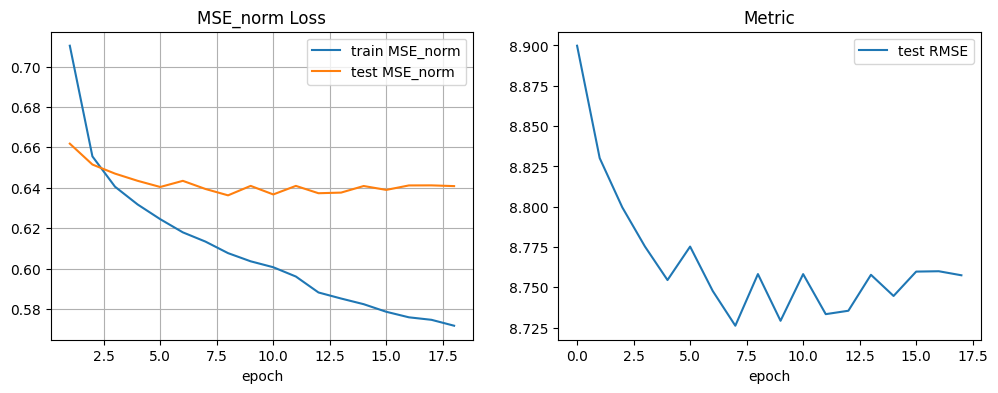

Early stopping at epoch 18
best model  test RMSE = 8.7262


In [ ]:
# ೭੧(❛〜❛✿)੭೨ Go forward!
n_epochs = 50
train_losses, test_losses, test_rmses = [], [], []
best_rmse = float("inf")
best_model_state = None # сохранение весов лучшей модели
early_stopping = 10
early_stopping_counter = 0
for epoch in range(n_epochs):
    # Обучение модели
    train_loss = train(model, optimizer, criterion, train_loader,test_loader)
    train_losses.append(train_loss)

    # Предсказания и считывание лосса с метрикой
    predicts = test(model, criterion, test_loader)
    test_loss = criterion(predicts.view(-1, 1), y_test_tensor).item()
    # умножаем RMSE на std_train, потому что RMSE считается в нормированных единицах
    # Перед обучением предварительно нормализовали целевую переменную
    test_rmse = (test_loss ** 0.5) * std_train
    scheduler.step(test_rmse)

    test_losses.append(test_loss)
    test_rmses.append(test_rmse)
    if test_rmse < best_rmse:
        best_rmse = test_rmse
        best_model_state = model.state_dict()
        early_stopping_counter = 0
    else:
        early_stopping_counter += 1

    # Динамическая отрисовка графика
    clear_output(wait=False)
    print(f"Epoch {epoch+1}/{n_epochs}: train MSE={train_loss:.4f}, test RMSE={test_rmse:.4f}")
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    current_epochs = range(1, len(train_losses) + 1)
    plt.plot(current_epochs, train_losses, label="train MSE_norm")
    plt.plot(current_epochs, test_losses, label="test MSE_norm")
    plt.xlabel("epoch")
    plt.legend()
    plt.title("MSE_norm Loss")
    plt.grid(True)


    plt.subplot(1, 2, 2)
    plt.plot(test_rmses, label="test RMSE")
    plt.xlabel("epoch"); plt.legend(); plt.title("Metric")
    plt.show()


    if early_stopping_counter >= early_stopping:
        print(f"Early stopping at epoch {epoch+1}")
        break


if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"best model  test RMSE = {best_rmse:.4f}")




## Задание 3. (0 баллов, но при невыполнении максимум за все задание &mdash; 0 баллов)

Напишите небольшой отчет о том, как вы добились полученного качества: какие средства использовали и какие эксперименты проводили. Подробно расскажите об архитектурах и значениях гиперпараметров, а также какие метрики на тесте они показывали. Чтобы отчет был зачтен, необходимо привести хотя бы 3 эксперимента.

## Задание 3. Отчёт по подбору модели

Архитектура: in_features(90) → Linear(256) → BatchNorm1d → ReLU → Dropout → Linear(128) → BatchNorm1d → ReLU → Dropout → Linear(64) → ReLU → Dropout → Linear(1).

Таргет нормирован через StandardScaler, во время обучения столбец целевой переменной нормировался, из-за чего метрику RMSE пришлось переводить обратно  с домножением на std_train. Из оптимизации взял AdamW и scheduler ReduceLROnPlateau чекпоинт весов на лучшей эпохе по test RMSE, early stopping.

| # | Конфигурация | Итог |
|---|---|---|
| 1 | Adam(lr=1e-3, wd=1e-5), StepLR(20, 0.7), dropout=0.3 только перед выходом | RMSE≈8.76 на 2-3 эпохе, затем переобучение: к 8-й эпохе RMSE > 9 |
| 2 | Та же сеть, ReLU заменён на SELU. Ещё хуже baseline: RMSE монотонно растёт с 9.10 до 9.20 за 7 эпох. Одна из причин, которые я прочитал: SELU требует LeCun-инициализации, AlphaDropout и отсутствия BatchNorm. |
| 3 | AdamW(lr=3e-4→1e-4, wd=1e-3), ReduceLROnPlateau(patience=4), dropout=0.05 только перед выходом | RMSE≈8.76-8.79. Причина в низкой регуляризации `dropout`, в scheduler LR `ReduceLROnPlateau` тоже нужно было увеличить действие регуляризации, а именно домножать `LR` на меньшую константу, то есть с `factor=0.7` уменьшил до `0.5`, уменьшил patience с `4` до `2`. Поэтому градиент не мог сойтись ближе к минимуму |
| 4 (финал) | AdamW(lr=1e-4, wd=1e-3), ReduceLROnPlateau(factor=0.5, patience=2), dropout=0.15 после каждого блока и перед выходом | test RMSE = 8.7262, early stopping на 18-й эпохе. |
